# **PRISM ALGORITHM**

# Installation

The main page for PRISM rules is from https://towardsdatascience.com/prism-rules-in-python-14d2cfd801a3/

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification, make_blobs, fetch_openml
import sklearn.datasets as datasets
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,f1_score
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype


class PrismRules:
    def __init__(self, min_coverage=10, min_prob=0.75, nbins=3, verbose=0):
        """
        Class to generate PRISM rules for a supplied dataset.

        :param min_coverage: The minimum number of rows each rule must cover.
        :param min_prob: The minimum probability for each rule. The target class must be the target value in the
            remaining rows (the rows not covered by previous rules) with at least this probability.
        :param nbins: The number of bins each numeric column is divided into.
        :param verbose: If 0, no output is produced other than the induced rules. If 1, progress indication is
            presented as each rule is induced.
        """

        self.min_coverage = min_coverage
        self.min_prob = min_prob
        self.nbins = nbins
        self.bin_ranges = {}
        self.verbose = verbose
        self.default_target = None
        self.predict_dict = {}
        self.target_column = ""

        # For improved performance, integer values are used for each value. This dictionary maps the integer codes
        # to the original values, and is used to display the rules and target values. Where the column is numeric,
        # this maps to the bin label.
        self.int_to_values_map = {}

    def __get_next_term(self, df, target_col, target_val, cols_exclude_list):
        """
        Get the next term (a column-value pair) for the current rule.

        :param df: The dataframe for the current rule. This is the set of rows matching the rule so far.
        :param target_col: Target column
        :param target_val: The current target value within the target column
        :param cols_exclude_list: Columns for which we already have terms for this rule.
        :return: a single term in tuple format, with a column name and value from that column, along with the
            probability and coverage (frequency) of the rule on the remaining rows.
        """

        max_prob = -1
        # In the event of ties with respect to probability, we take the term with the greatest frequency
        max_prob_freq = 0
        term = None
        for col_name in df.drop(columns=[target_col]).columns:
            if col_name in cols_exclude_list:
                continue
            for val in df[col_name].unique():
                sub_df_1 = df[df[col_name] == val]
                sub_df_2 = df[(df[col_name] == val) & (df[target_col] == target_val)]
                prob = len(sub_df_2) / len(sub_df_1)
                freq = len(sub_df_2)
                if freq < self.min_coverage:
                    continue
                if (prob > max_prob) or ((prob == max_prob) and (freq > max_prob_freq)):
                    max_prob = prob
                    max_prob_freq = freq
                    term = (col_name, val, prob, freq)
        return term

    def __get_next_rule(self, df_rule, target_col, target_val):
        """
        Given a specified target_val in the target_col, find the first or next rule. If not the first, the dataframe
        should just contain rows not covered by the previous rules for this target value.

        :param df_rule: the full original dataframe, minus the rows covered by other rules for the current target
        :param target_col: the target column
        :param target_val: the target value
        :return: a list of terms for the new rule, and a dataframe with the rows for this rule
        """

        terms_list = []
        cols_exclude_list = []  # Do not create terms for the same feature in the same rule
        df = df_rule.copy()
        target_val_remaining = df[target_col].tolist().count(target_val)
        len_df = len(df)
        while target_val_remaining < len_df:
            term = self.__get_next_term(df, target_col, target_val, cols_exclude_list)
            if term is None:
                break
            col, val, prob, freq = term
            cols_exclude_list.append(col)
            if len(cols_exclude_list) == (len(df.columns) - 1):
                break
            df = df[(df[col] == val)]
            terms_list.append((term, df))
            target_val_remaining = df[target_col].tolist().count(target_val)
            len_df = len(df)

        # Check the terms list for the optimal set of terms, which is the set with the highest probability of the
        # target class given the terms.
        max_prob = 0
        max_prob_idx = -1
        max_prob_df = None
        for term_idx, term in enumerate(terms_list):
            if term[0][2] > max_prob:
                max_prob = term[0][2]
                max_prob_idx = term_idx
                max_prob_df = term[1]
        optimal_terms_list = terms_list[:max_prob_idx + 1]
        optimal_terms_list = [x for x, y in optimal_terms_list]

        if max_prob < self.min_prob:
            return None, None

        # Convert the integer codes used in the dataframe to the original values for the relevant column
        formatted_terms = []
        for t in optimal_terms_list:
            if t[1] == "NONE":
                formatted_terms.append(t)
            else:
                formatted_terms.append((t[0], self.int_to_values_map[t[0]][t[1]], t[2], t[3]))

        return formatted_terms, max_prob_df

    def __get_rules_for_target_val(self, df_full, target_col, target_val):
        """
        Get the full set of rules for the specified value in the target column
        :param df_full:
        :param target_col:  Name of target column
        :param target_val:  Value in the target column for which this execution of this function generates rules.
        :return: array of strings.
        """

        rules_for_val = []
        num_rows_curr_target = df_full[target_col].tolist().count(target_val)
        df = df_full.copy()  # Create a temporary dataframe that shrinks as the rules are formed
        is_first_rule = True
        target_val_remaining = df[target_col].tolist().count(target_val)
        while target_val_remaining > self.min_coverage:
            if self.verbose:
                print(f"  Determining next rule. {target_val_remaining:,} rows remaining for target class")
            num_rows_curr_target_remaining = df[target_col].tolist().count(target_val)
            terms_list, rule_df = self.__get_next_rule(df, target_col, target_val)
            if not terms_list:
                break

            if target_val in self.predict_dict:
                self.predict_dict[target_val].append(terms_list)
            else:
                self.predict_dict[target_val] = [terms_list]

            # Add a rule in string format representing the list of terms returned
            rule_str = ""
            for term in terms_list:
                rule_str += str(term[0]) + " = " + str(term[1]) + " AND "
            rule_str = rule_str[:-5]  # Remove the trailing "AND"
            num_matching_target = rule_df[target_col].tolist().count(target_val)
            rule_str += "\n   Support:  "
            if is_first_rule:
                rule_str += f"the target has value: '{self.int_to_values_map[target_col][target_val]}' for "
                rule_str += f"{terms_list[-1][2] * 100:.3f}% of the {num_matching_target} rows matching the rule "
                rule_str += "\n   Coverage: "
                rule_str += f"the rule matches: {num_matching_target} out of {num_rows_curr_target} rows "
                rule_str += f"for target value: '{self.int_to_values_map[target_col][target_val]}'. This is:"
            else:
                rule_str += f"The target has value: '{self.int_to_values_map[target_col][target_val]}' for "
                rule_str += f"{terms_list[-1][2] * 100:.3f}% of the {num_matching_target} remaining rows matching the "
                rule_str += "rule"
                rule_str += "\n   Coverage: "
                rule_str += f"The rule matches: {num_matching_target} out of {num_rows_curr_target_remaining} rows "
                rule_str += f"remaining for target value: '{self.int_to_values_map[target_col][target_val]}'. This is:"
                rule_str += f"\n      {(num_matching_target * 100.0 / num_rows_curr_target_remaining):.3f}% of "
                rule_str += f"remaining rows for target value: '{self.int_to_values_map[target_col][target_val]}'"
            rule_str += f"\n      {(num_matching_target * 100.0 / num_rows_curr_target):.3f}% of total rows for target "
            rule_str += f"value: '{self.int_to_values_map[target_col][target_val]}'"
            rule_str += f"\n      {(num_matching_target * 100.0 / len(df_full)):.3f}% of total rows in data"
            rules_for_val.append(rule_str)
            is_first_rule = False

            # Remove all rows for this rule
            df = df.loc[list(set(df.index) - set(rule_df.index))]
            target_val_remaining = df[target_col].tolist().count(target_val)
        return rules_for_val

    def __display_rules(self, df, target_col, rules_dict, display_stats):
        for target_val in rules_dict:
            print()
            print('........................................................................')
            print(f"Target: {self.int_to_values_map[target_col][target_val]}")
            print('........................................................................')
            if len(rules_dict[target_val]) == 0 and display_stats:
                print((f"  No rules imputed for target value {self.int_to_values_map[target_col][target_val]}. There "
                       f"are {df[target_col].tolist().count(target_val)} rows for this class."))
            for r in rules_dict[target_val]:
                if display_stats:
                    print(r)
                else:
                    print(r.split("\n")[0])

    def get_prism_rules(self, df, target_col, display_stats=True):
        """
        Given a dataframe with a specified target column, find a set of rules that describe the patterns associated
        with the target column. The rules are displayed in a formatted form.

        :param df: pandas dataframe. Must include the target column.
        :param target_col: Name of the target column
        :param display_stats: If True, the support and coverage for each rule will be displayed
        :return: array of strings, with each element of the array representing one rule.
        """

        # PRISM requires all columns be categorical, so bin any numeric features, including the target column if
        # necessary.
        new_vals_dict = {}
        for col_name in df.columns:
            if is_numeric_dtype(df[col_name]) and (df[col_name].nunique() > 10):
                try:
                    if self.nbins == 3:
                        vals = ['Low', "Med", 'High']
                        bin_ids, bin_ranges = pd.qcut(df[col_name], 3, labels=vals, retbins=True)
                    else:
                        vals = [f"Bin_{x}" for x in range(self.nbins)]
                        bin_ids, bin_ranges = pd.qcut(df[col_name], self.nbins, labels=vals, retbins=True)
                    self.bin_ranges[col_name] = bin_ranges
                    vals_to_int_map = {x: y for x, y in zip(vals, range(len(vals)))}
                    int_to_vals_map = {y: x for x, y in zip(vals, range(len(vals)))}
                    new_vals_dict[col_name] = bin_ids.map(vals_to_int_map)
                    self.int_to_values_map[col_name] = int_to_vals_map
                except:
                    # The qcut() method may fail if the data is sufficiently skewed, and the bins are non-unique, In
                    # this case we do not include the column in the model.
                    pass
            else:
                vals = df[col_name].unique()
                vals_to_int_map = {x: y for x, y in zip(vals, range(len(vals)))}
                int_to_vals_map = {y: x for x, y in zip(vals, range(len(vals)))}
                new_vals_dict[col_name] = df[col_name].map(vals_to_int_map)
                self.int_to_values_map[col_name] = int_to_vals_map
        df = pd.DataFrame(new_vals_dict)

        # Remove any columns with only 1 unique value
        drop_cols = []
        for col_name in df.columns:
            if df[col_name].nunique() < 2:
                drop_cols.append(col_name)
        df = df.drop(columns=drop_cols)

        # Fill any NaN and None values
        for col_name in df.columns:
            if df[col_name].dtype.name == "category":
                df[col_name] = df[col_name].cat.add_categories("NONE").fillna("NONE")
            else:
                df[col_name] = df[col_name].fillna("NULL")

        # Loop through each value in the target column and find the set of rules for this value
        target_vals = sorted(df[target_col].unique())
        if self.verbose:
            print(f"Determining rules for each of {len(target_vals)} target classes:")
        rules_dict = {}
        for target_val in target_vals:
            if self.verbose >= 1:
                print(f"Determining rules for target class: {self.int_to_values_map[target_col][target_val]}")
            rules_dict[target_val] = self.__get_rules_for_target_val(df, target_col, target_val)

        self.__display_rules(df, target_col, rules_dict, display_stats)

        self.default_target = df[target_col].mode().values[0]
        self.target_column = target_col

        return rules_dict

    def predict(self, X_in, leave_unknown=False):
        X = X_in.copy()
        X = X.reset_index(drop=True)
        if leave_unknown:
            ret = ["NO PREDICTION"]*len(X)
        else:
            ret = [self.default_target]*len(X)
        is_set = [False]*len(X)

        for col_name in X.columns:
            if col_name not in self.bin_ranges:
                continue
            bin_ranges = self.bin_ranges[col_name]
            for i in range(len(X)):
                v = X.loc[i, col_name]
                for bin_idx, bin_limit in enumerate(bin_ranges):
                    if v < bin_limit:
                        X.loc[i, col_name] = bin_idx - 1
                        break
            if col_name in self.int_to_values_map:
                X[col_name] = X[col_name].map(self.int_to_values_map[col_name])

        for i in range(len(X)):
            row = X.iloc[i]
            found_rule = False
            for key in self.predict_dict.keys():
                rules = self.predict_dict[key]
                for rule in rules:
                    all_terms_true = True
                    for term in rule:
                        term_feature_name = term[0]
                        term_value = term[1]
                        if row[term_feature_name] != term_value:
                            all_terms_true = False
                            break
                    if all_terms_true:
                        ret[i] = key
                        is_set[i] = True
                        found_rule = True
                        break
                if found_rule:
                    break
        ret = pd.Series(ret).map(self.int_to_values_map[self.target_column])
        if leave_unknown:
            ret = ret.fillna("NO PREDICTION")
            ret = ret.astype(str)
        return ret

    def get_bin_ranges(self):
        if self.bin_ranges is None:
            print("No columns were binned.")
        else:
            return self.bin_ranges


# Load Dataset

In [53]:
# load dataset, features only
df = pd.read_csv('https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/wine_data.csv')
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Y
0,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0,0
1,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.20,0.61,1.60,560.0,2
2,12.16,1.61,2.31,22.8,90.0,1.78,1.69,0.43,1.56,2.45,1.33,2.26,495.0,1
3,13.07,1.50,2.10,15.5,98.0,2.40,2.64,0.28,1.37,3.70,1.18,2.69,1020.0,0
4,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Y    

In [42]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Y
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [43]:
df = df.sample(n=len(df)) # Shuffle the rows
print("Number of rows:", len(df))

Number of rows: 178


## Distribution of Flavanoids vs Total Phenols Across Wine Categories


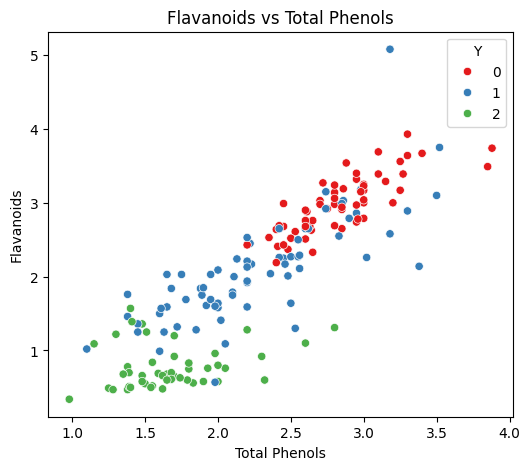

In [44]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='total_phenols', y='flavanoids', hue='Y', palette='Set1')
plt.title('Flavanoids vs Total Phenols')
plt.xlabel('Total Phenols')
plt.ylabel('Flavanoids')
plt.show()


Pada visualisasi scatterplot Flavanoids vs Total Phenols ini, terlihat pola yang cukup jelas antara kedua variabel. Secara umum, terdapat korelasi positif: semakin tinggi nilai total phenols, nilai flavanoids juga cenderung meningkat. Selain itu, titik-titik data terbagi menjadi tiga cluster sesuai kelas Y (jenis wine), yang ditandai dengan warna berbeda: merah (0), biru (1), dan hijau (2). Cluster hijau berada di area dengan total phenols dan flavanoids rendah, biru berada di tengah, dan merah berada di nilai yang lebih tinggi. Pola ini menunjukkan bahwa kombinasi flavanoids dan total phenols dapat menjadi indikator yang kuat untuk membedakan jenis wine dalam dataset ini. Secara visual, setiap kelas memiliki rentang nilai yang relatif terpisah, meskipun ada beberapa overlap antara kelas merah dan biru.

## Correlation Heatmap of Wine Features

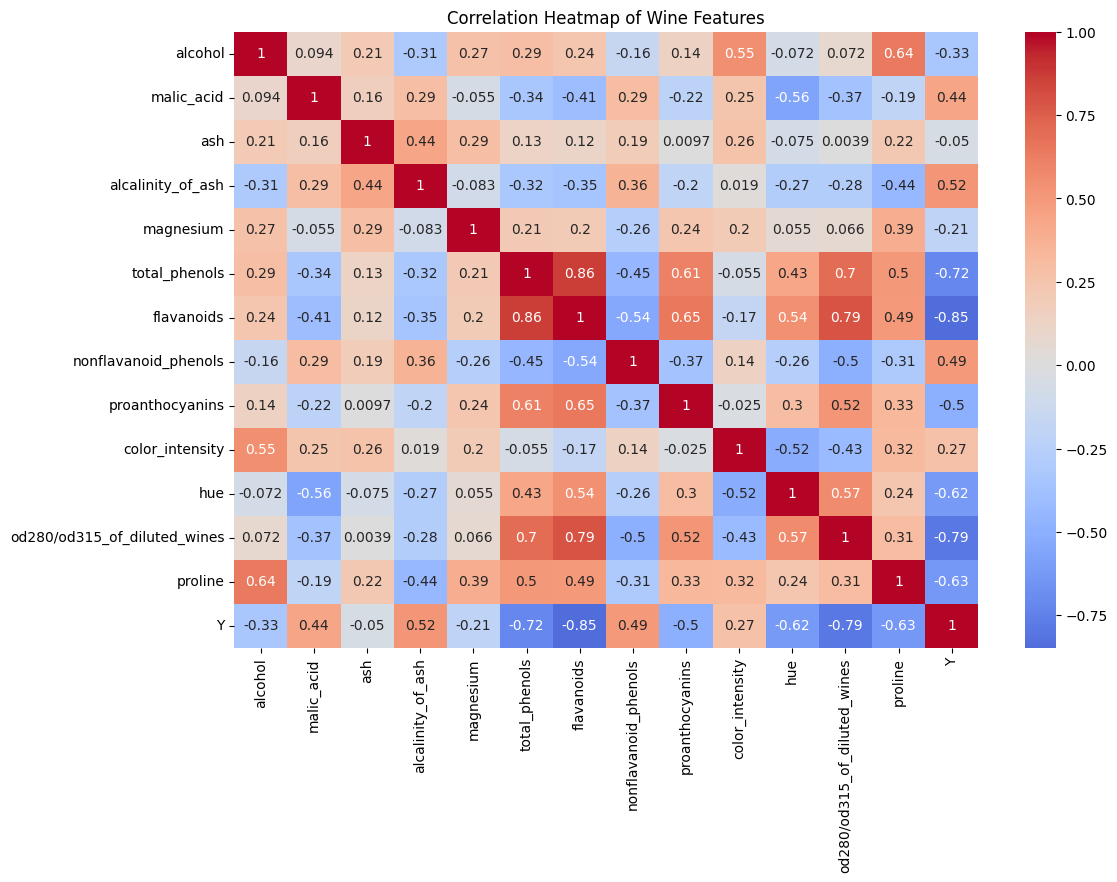

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Wine Features')
plt.show()

Heatmap korelasi di atas memperlihatkan hubungan antar fitur kimia pada dataset wine. Dari visualisasi ini, terdapat beberapa pola menarik yang dapat diamati.

Fitur flavanoids memiliki korelasi positif yang sangat tinggi dengan total_phenols (0.86), menunjukkan bahwa semakin tinggi kadar flavanoid, semakin tinggi pula total phenol pada wine tersebut. Sebaliknya, flavanoids menunjukkan korelasi negatif kuat dengan Y (-0.85), yang berarti semakin tinggi flavanoid, kemungkinan kelas target (Y) cenderung lebih rendah.

Fitur hue juga berkorelasi negatif cukup tinggi dengan Y (-0.62), menandakan bahwa semakin rendah nilai hue, semakin besar kemungkinan wine tersebut masuk ke kelas dengan nilai Y lebih tinggi. Selain itu, od280/od315_of_diluted_wines memiliki korelasi negatif sangat kuat dengan Y (-0.79), menjadikannya salah satu fitur yang paling berpengaruh terhadap kelas wine.

Sementara itu, alcalinity_of_ash menunjukkan korelasi positif sedang dengan Y (0.52), menunjukkan bahwa kadar alkalinitas abu yang tinggi cenderung terkait dengan kelas wine bernilai lebih tinggi. Sebaliknya, alcohol memiliki korelasi negatif sedang dengan Y (-0.33), yang berarti semakin tinggi kadar alkohol, kelas target cenderung lebih rendah.

Terdapat juga hubungan antar fitur yang kuat, seperti flavanoids dengan proanthocyanins (0.65) dan flavanoids dengan od280/od315_of_diluted_wines (0.79), yang menunjukkan adanya keterkaitan kimiawi di antara komponen tersebut.

Secara keseluruhan, heatmap ini membantu mengidentifikasi fitur-fitur yang saling berhubungan serta fitur-fitur yang berpotensi kuat sebagai prediktor untuk menentukan kelas wine. Korelasi negatif tinggi dengan Y seperti pada flavanoids, od280/od315_of_diluted_wines, dan hue, menunjukkan bahwa fitur-fitur tersebut sangat relevan dalam proses klasifikasi wine.

# Generate Rules with PRISM

In [55]:
# since we dont do any partitioning bcs we have to use both X and Y in our 'prism' model, so let's just use 100 rows for this training and the rest for the testing

# PRISM requires all columns be categorical, so bin any numeric features, including the target column if necessary, BUT there's a binning function in 'get_prism_rules', so we dont need to binning it manually first.

prism = PrismRules()
_ = prism.get_prism_rules(df.head(100), 'Y')


........................................................................
Target: 0
........................................................................
proline = High AND flavanoids = High
   Support:  the target has value: '0' for 100.000% of the 25 rows matching the rule 
   Coverage: the rule matches: 25 out of 29 rows for target value: '0'. This is:
      86.207% of total rows for target value: '0'
      25.000% of total rows in data

........................................................................
Target: 2
........................................................................
flavanoids = Low AND hue = Low
   Support:  the target has value: '2' for 100.000% of the 23 rows matching the rule 
   Coverage: the rule matches: 23 out of 26 rows for target value: '2'. This is:
      88.462% of total rows for target value: '2'
      23.000% of total rows in data

........................................................................
Target: 1
............................

### Target: 0

Rule: ***IF proline = High AND flavanoids = High → Class 0***

#### Interpretasi:
- Wine dengan kadar proline tinggi dan flavanoid tinggi cenderung termasuk dalam kelas 0. Kombinasi ini menunjukkan karakteristik wine yang kaya senyawa kimia dan berpotensi memiliki kualitas tinggi atau tingkat kematangan tertentu—ciri khas pada kelas 0.

#### Kekuatan Aturan:

- Support: 100% → Semua 25 data yang memenuhi rule ini benar-benar berasal dari kelas 0, menunjukkan akurasi sempurna.
- Coverage: Rule ini mencakup 86.21% dari seluruh anggota kelas 0, artinya mayoritas besar kelas 0 mengikuti pola ini.


### Target: 2

Rule: ***IF flavanoids = Low AND hue = Low → Class 2***

#### Interpretasi:
- Wine dengan flavanoid rendah dan hue rendah (warna dasar pudar) cenderung termasuk ke dalam kelas 2.
Meskipun warnanya tampak lebih lembut, kombinasi ini menunjukkan adanya karakteristik kimia unik yang khas pada kelas 2.

#### Kekuatan Aturan:

- Support: 100% → Semua 23 data yang memenuhi rule ini berasal dari kelas 2, tanpa kesalahan.
- Coverage: Rule ini mencakup 88.46% dari total anggota kelas 2, menandakan bahwa hampir seluruh kelas 2 mengikuti pola ini.

### Target: 1

Rule: ***IF color_intensity = Low → Class 1***

#### Interpretasi:
- Wine dengan intensitas warna rendah cenderung termasuk ke dalam kelas 1. Hal ini mengindikasikan bahwa tipe anggur dengan warna lebih ringan dan kadar alkohol yang umumnya juga tidak terlalu tinggi sering masuk ke kategori ini.

#### Kekuatan Aturan:

- Support: 100% → Semua 33 data yang memenuhi rule ini berasal dari kelas 1, menunjukkan keandalan tinggi.
- Coverage: Rule ini mencakup 73.33% dari seluruh data kelas 1, sehingga lebih dari dua pertiga anggota kelas ini dapat dijelaskan oleh pola tersebut.

# Bin Ranges Result

In [60]:
# This section only to know the range of the bins
bin_ranges_data = []
for col, ranges in prism.get_bin_ranges().items():
    counts, _ = np.histogram(df[col], bins=ranges)
    for i in range(len(ranges) - 1):
        bin_ranges_data.append({
            'Column': col,
            'Bin': i,
            'Lower Bound': ranges[i],
            'Upper Bound': ranges[i+1],
            'Bin': i,
            'Count': counts[i]
        })

bin_ranges_df = pd.DataFrame(bin_ranges_data)
display(bin_ranges_df)

,Column,Bin,Lower Bound,Upper Bound,Count
0,alcohol,0,11.03,12.42,51
1,alcohol,1,12.42,13.40,62
2,alcohol,2,13.40,14.39,63
3,malic_acid,0,0.90,1.68,58
4,malic_acid,1,1.68,2.56,59
5,malic_acid,2,2.56,5.51,57
6,ash,0,1.36,2.27,56
7,ash,1,2.27,2.48,61
8,ash,2,2.48,2.92,59
9,alcalinity_of_ash,0,10.60,18.50,64


# Test on Y Pred

In [61]:
# we use the rest of our data for testing, in this case is 50 rows
y_pred = prism.predict(df.tail(50).drop(columns=['Y']))
f1_score(df.tail(50)['Y'], y_pred, average=None)

array([0.77419355, 0.7804878 , 0.92857143])

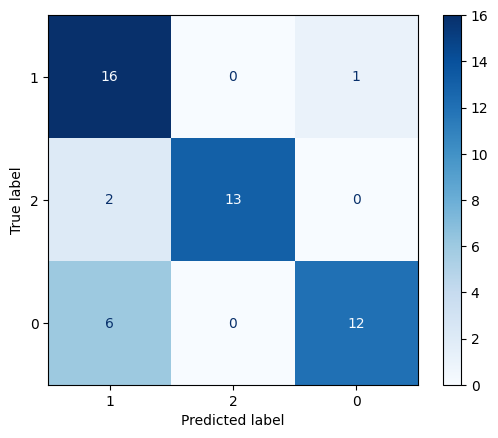

In [62]:
# We next display the confusion matrix.
labels = y_pred.unique()
cm = confusion_matrix(df.tail(50)['Y'], y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.show()

- Class 2 memiliki performa terbaik, sebagian besar sampel kelas 2 diprediksi dengan benar (13 benar, hanya 2 salah).

- Class 1 juga menunjukkan hasil yang kuat, dengan 16 dari 17 prediksi benar (tingkat akurasi sangat tinggi).

- Class 0 memiliki performa yang sedikit lebih lemah, terdapat 6 kesalahan prediksi ke kelas 1, menunjukkan bahwa model kadang kesulitan membedakan kelas 0 dan kelas 1.

In [63]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(df.tail(50)['Y'], y_pred))

              precision    recall  f1-score   support

           0       0.92      0.67      0.77        18
           1       0.67      0.94      0.78        17
           2       1.00      0.87      0.93        15

    accuracy                           0.82        50
   macro avg       0.86      0.82      0.83        50
weighted avg       0.86      0.82      0.82        50



#### Class 0

- Precision 0.92: Prediksi kelas 0 hampir selalu benar saat model menebak “ini kelas 0”.
- Recall 0.67: Tapi hanya 67% dari seluruh kelas 0 yang berhasil dikenali — artinya beberapa contoh kelas 0 keliru dikira kelas lain (terutama kelas 1).
- Kesimpulan: Model cukup hati-hati (presisi tinggi) tapi masih melewatkan sebagian contoh kelas 0.

#### Class 1

- Precision 0.67: Beberapa prediksi kelas 1 ternyata bukan kelas 1 (masih ada salah klasifikasi).
- Recall 0.94: Sebagian besar kelas 1 berhasil terdeteksi dengan benar.
- Kesimpulan: Model sangat baik dalam mengenali kelas 1, tapi kadang overpredict (mengira kelas lain sebagai kelas 1).

#### Class 2

- Precision 1.00: Semua prediksi kelas 2 benar
- Recall 0.87: Ada sedikit data kelas 2 yang tidak tertangkap.
- Kesimpulan: Rule untuk kelas 2 paling kuat dan spesifik, menunjukkan fitur pembeda yang jelas untuk kelas ini.

## Which class is predicted best?

Kelas 2 adalah yang diprediksi paling baik.
Kelas ini memiliki precision tertinggi (1.00) dan F1-score kuat (0.93) — artinya semua prediksi yang diklasifikasikan sebagai kelas 2 benar, dan sebagian besar data asli kelas 2 juga berhasil dikenali.
Ini menunjukkan bahwa rule yang dihasilkan untuk kelas 2 sangat kuat dan spesifik, sehingga model dapat membedakan kelas ini dengan jelas dari kelas lainnya.

## Are there misclassifications?

Ya, terdapat beberapa kesalahan klasifikasi:
- Beberapa data kelas 0 salah diklasifikasikan sebagai kelas 1 (6 kasus).
- Beberapa data kelas 2 salah diklasifikasikan sebagai kelas 1 (2 kasus).
- Dan 1 data kelas 1 salah diklasifikasikan sebagai kelas 0.

Kesalahan ini menunjukkan bahwa kelas 0 dan kelas 1 memiliki karakteristik fitur yang mirip, terutama pada variabel seperti alcohol dan color_intensity, sehingga model PRISM kadang kesulitan membedakannya secara sempurna.

In [64]:
# Create new data points for the Iris dataset
# You can change these values to test different scenarios
new_data = {
   'alcohol': [14.0, 14.0],
   'malic_acid': [2.0, 2.0],
   'ash': [2.3, 2.2],
   'alcalinity_of_ash': [19.0, 11.0],
   'magnesium': [95.0, 95.0],
   'total_phenols': [2.2, 2.5],
   'flavanoids': [0.14, 0.5],
   'nonflavanoid_phenols': [0.14, 0.5],
   'proanthocyanins': [1.6, 1.5],
   'color_intensity': [7.0, 6.0],
   'hue': [0.7, 0.6],
   'od280/od315_of_diluted_wines': [3.2, 3.0],
   'proline': [550.0, 1400.0]
}

new_df = pd.DataFrame(new_data)

# Predict on the new Iris data using the prism model trained on Iris data
iris_prediction = prism.predict(new_df)
# Assign predictions to a new column in the DataFrame
new_df['Predicted Class'] = iris_prediction

# Display the new data and prediction
print("New Iris Data Points:")
display(new_df)

New Iris Data Points:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Predicted Class
0,14.0,2.0,2.3,19.0,95.0,2.2,0.14,0.14,1.6,7.0,0.7,3.2,550.0,1
1,14.0,2.0,2.2,11.0,95.0,2.5,0.50,0.50,1.5,6.0,0.6,3.0,1400.0,2


## **Data Point 1**

Predicted Class: 1
Feature summary:

- Alcohol = 14.0 (tinggi)
- Color intensity = 7.0 (cukup tinggi)
- Flavanoids = 0.14 (rendah)
- Alkalinity of ash = 19.0 (cukup tinggi)
- Proline = 550 (menengah)

#### Rule :
***color_intensity = Low AND alcohol = Low → Class 1***

Walaupun alcohol dan color_intensity tidak benar-benar "low", data ini memiliki flavanoid rendah dan karakteristik kimia moderat (tidak menonjol ke arah kelas 0 atau 2).
Karena tidak cocok dengan rule kuat untuk kelas 0 (proline tinggi, alkalinity rendah) atau kelas 2 (flavanoid rendah + hue rendah + color_intensity tinggi) secara penuh, PRISM memilih kelas 1 sebagai kategori paling sesuai berdasarkan kombinasi kemiripan pola dari data training.

#### Interpretasi :
Anggur ini kemungkinan termasuk dalam kelas 1 — yaitu tipe wine dengan karakteristik sedang: tidak terlalu kuat dalam proline dan tidak terlalu pekat secara warna. Model menilai profilnya lebih dekat ke kelas 1 dibandingkan ke kelas lain.

## **Data Point 2**

Predicted Class: 2
Feature summary:

- Alcohol = 14.0 (tinggi)
- Flavanoids = 0.50 (rendah)
- Hue = 0.6 (rendah)
- Color intensity = 6.0 (tinggi)
- Proline = 1400 (sangat tinggi)

#### Rule :

***flavanoids = Low AND hue = Low AND color_intensity = High → Class 2***

Data kedua ini cocok secara langsung dengan rule PRISM untuk kelas 2:

- Flavanoid rendah
- Hue rendah
- Color intensity tinggi

Ketiga kondisi ini terpenuhi secara sempurna, sehingga model PRISM mengklasifikasikannya dengan tingkat keyakinan tinggi ke Class 2.
Karakteristik ini menunjukkan bahwa wine tersebut memiliki warna yang pekat namun kadar flavanoid dan hue yang rendah ciri khas dari kelas 2 dalam data training.

#### Interpretasi :
Wine ini cenderung kelas 2, yang secara kimia dicirikan oleh warna pekat (color_intensity tinggi) tetapi flavanoid dan hue rendah.
Dengan support 100% pada rule tersebut di data training, prediksi ini sangat kuat dan dapat dipercaya.